In [ ]:
# Mount Drive and verify all inputs

from google.colab import drive
drive.mount('/content/drive')

import os, torch, numpy as np

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

STGCN_CKPT       = '/content/drive/MyDrive/HRC_Research/checkpoints/stgcn_hri30/best_stgcn_hri30.pt'
CTRGCN_CKPT      = '/content/drive/MyDrive/HRC_Research/checkpoints/ctrgcn_hri30/best_ctrgcn_hri30.pt'
STGCN_TEST_DATA  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/stgcn_format/test_data.npy'
STGCN_TEST_LABEL = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/stgcn_format/test_label.pkl'
CTRGCN_TEST_NPZ  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/ctrgcn_format/HRI30_CS.npz'

OUTPUT_DIR = '/content/drive/MyDrive/HRC_Research/results/ablation_fusion'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"\nOutput folder ready: {OUTPUT_DIR}")

checks = [
    ("ST-GCN checkpoint",  STGCN_CKPT),
    ("CTR-GCN checkpoint", CTRGCN_CKPT),
    ("ST-GCN test data",   STGCN_TEST_DATA),
    ("ST-GCN test labels", STGCN_TEST_LABEL),
    ("CTR-GCN npz",        CTRGCN_TEST_NPZ),
]

all_ok = True
print("\n--- File verification ---")
for name, path in checks:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024**2
        print(f"  OK      {name}: {size_mb:.1f} MB")
    else:
        print(f"  MISSING {name}: {path}")
        all_ok = False

if all_ok:
    print("\nAll inputs found.")
else:
    print("\nFix missing files before continuing.")

Mounted at /content/drive
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4

Output folder ready: /content/drive/MyDrive/HRC_Research/results/ablation_fusion

--- File verification ---
  OK      ST-GCN checkpoint: 11.9 MB
  OK      CTR-GCN checkpoint: 5.8 MB
  OK      ST-GCN test data: 25.2 MB
  OK      ST-GCN test labels: 0.0 MB
  OK      CTR-GCN npz: 126.2 MB

All inputs found.


In [ ]:
# Clone repos, patch, and load both fine-tuned HRI30 models

import os, sys, torch
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type != 'cuda':
    print("WARNING: No GPU. Switch to T4 GPU before Cell 4.")

STGCN_DIR  = '/content/st-gcn'
CTRGCN_DIR = '/content/CTR-GCN'

if not os.path.exists(STGCN_DIR):
    os.system(f'git clone https://github.com/yysijie/st-gcn.git {STGCN_DIR}')
    print("ST-GCN cloned.")
else:
    print("ST-GCN already present.")

stgcn_io = Path(f'{STGCN_DIR}/torchlight/torchlight/io.py')
text = stgcn_io.read_text()
if 'weights_only=False' not in text:
    text = text.replace(
        'torch.load(weights_path)',
        'torch.load(weights_path, weights_only=False, map_location="cpu")'
    )
    stgcn_io.write_text(text)
    print("ST-GCN torch.load patch applied.")
else:
    print("ST-GCN patch already present.")

os.system(f'pip install -e {STGCN_DIR}/torchlight -q')

if not os.path.exists(CTRGCN_DIR):
    os.system(f'git clone https://github.com/Uason-Chen/CTR-GCN.git {CTRGCN_DIR}')
    print("CTR-GCN cloned.")
else:
    print("CTR-GCN already present.")

os.system('pip install -q tensorboardX torchpack fvcore iopath yacs thop')
os.system(f'pip install -e {CTRGCN_DIR}/torchlight -q')

ctrgcn_util = Path(f'{CTRGCN_DIR}/torchlight/torchlight/util.py')
text = ctrgcn_util.read_text()
if 'PaviLogger = None' not in text:
    text = text.replace(
        'from torchpack.runner.hooks import PaviLogger',
        'try:\n    from torchpack.runner.hooks import PaviLogger\nexcept ImportError:\n    PaviLogger = None'
    )
    ctrgcn_util.write_text(text)
    print("CTR-GCN torchpack patch applied.")
else:
    print("CTR-GCN patch already present.")

sys.path.insert(0, STGCN_DIR)
from net.st_gcn import Model as STGCN_Model

stgcn_model = STGCN_Model(
    in_channels=3, num_class=30, dropout=0.5,
    edge_importance_weighting=True,
    graph_args={'layout': 'ntu-rgb+d', 'strategy': 'spatial'}
)
stgcn_ckpt  = torch.load(STGCN_CKPT, map_location='cpu', weights_only=False)
stgcn_state = stgcn_ckpt['model_state_dict'] if isinstance(stgcn_ckpt, dict) and 'model_state_dict' in stgcn_ckpt else stgcn_ckpt
stgcn_state = {k[7:] if k.startswith('module.') else k: v for k, v in stgcn_state.items()}
stgcn_model.load_state_dict(stgcn_state, strict=True)
stgcn_model = stgcn_model.to(device).eval()
print("ST-GCN loaded (30 classes) ✓")

sys.path.insert(0, CTRGCN_DIR)
from model.ctrgcn import Model as CTRGCN_Model

ctrgcn_model = CTRGCN_Model(
    num_class=30, num_point=25, num_person=1,
    graph='graph.ntu_rgb_d.Graph',
    graph_args={'labeling_mode': 'spatial'}
)
ctrgcn_ckpt  = torch.load(CTRGCN_CKPT, map_location='cpu', weights_only=False)
ctrgcn_state = ctrgcn_ckpt['model_state_dict'] if isinstance(ctrgcn_ckpt, dict) and 'model_state_dict' in ctrgcn_ckpt else ctrgcn_ckpt
ctrgcn_state = {k[7:] if k.startswith('module.') else k: v for k, v in ctrgcn_state.items()}
ctrgcn_model.load_state_dict(ctrgcn_state, strict=True)
ctrgcn_model = ctrgcn_model.to(device).eval()
print("CTR-GCN loaded (30 classes) ✓")

print("\n[PASS] Both models ready.")

Using device: cuda
ST-GCN cloned.
ST-GCN torch.load patch applied.
CTR-GCN cloned.
CTR-GCN torchpack patch applied.
ST-GCN loaded (30 classes) ✓
CTR-GCN loaded (30 classes) ✓

[PASS] Both models ready.


In [ ]:
# Load test data

import numpy as np, pickle

STGCN_TEST_DATA  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/stgcn_format/test_data.npy'
STGCN_TEST_LABEL = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/stgcn_format/test_label.pkl'
CTRGCN_TEST_NPZ  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/ctrgcn_format/HRI30_CS.npz'

stgcn_test_data = np.load(STGCN_TEST_DATA)

with open(STGCN_TEST_LABEL, 'rb') as f:
    _, y_test = pickle.load(f)
stgcn_test_labels = np.array(y_test)

npz = np.load(CTRGCN_TEST_NPZ)
ctrgcn_test_data   = npz['x_test']
ctrgcn_test_labels = npz['y_test']

print(f"ST-GCN  test data:  {stgcn_test_data.shape}  labels: {stgcn_test_labels.shape}")
print(f"CTR-GCN test data:  {ctrgcn_test_data.shape}  labels: {ctrgcn_test_labels.shape}")

assert stgcn_test_data.shape[0] == ctrgcn_test_data.shape[0], "Sample count mismatch!"
assert (stgcn_test_labels == ctrgcn_test_labels).all(), "Label mismatch!"

labels_np = stgcn_test_labels
N = labels_np.shape[0]
print(f"\n{N} test samples, 30 classes, labels match.")

ST-GCN  test data:  (588, 3, 150, 25, 1)  labels: (588,)
CTR-GCN test data:  (588, 3, 150, 25, 1)  labels: (588,)

588 test samples, 30 classes, labels match.


In [ ]:
# Fusion Strategy Ablation

import numpy as np, csv, os, time, torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = '/content/drive/MyDrive/HRC_Research/results/ablation_fusion'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def apply_occlusion(data_np, rate, seed):
    """Identical to Phase 4 — same logic, same seed convention."""
    if rate == 0.0:
        return data_np.copy()
    np.random.seed(seed)
    data_out = data_np.copy()
    num_joints   = data_out.shape[3]
    num_to_zero  = max(1, int(round(num_joints * rate)))
    joints_zero  = np.random.choice(num_joints, num_to_zero, replace=False)
    data_out[:, :, :, joints_zero, :] = 0.0
    return data_out

def get_logits(model, data_np, batch_size=64):
    model.eval()
    all_logits = []
    with torch.no_grad():
        for start in range(0, data_np.shape[0], batch_size):
            batch = torch.tensor(
                data_np[start:start+batch_size], dtype=torch.float32
            ).to(device)
            all_logits.append(model(batch).cpu().numpy())
    return np.concatenate(all_logits)

def softmax_fn(logits):
    e = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def entropy_fn(probs):
    return -np.sum(probs * np.log(probs + 1e-9), axis=1)


def fuse_unweighted(logits_st, logits_ctr):
    """Strategy A: Simple average of softmax probabilities."""
    p_st  = softmax_fn(logits_st)
    p_ctr = softmax_fn(logits_ctr)
    return np.argmax((p_st + p_ctr) / 2.0, axis=1)

def fuse_max_confidence(logits_st, logits_ctr):
    """Strategy B: Per-sample selection of the more confident model."""
    p_st  = softmax_fn(logits_st)
    p_ctr = softmax_fn(logits_ctr)
    conf_st  = p_st.max(axis=1)
    conf_ctr = p_ctr.max(axis=1)
    preds_st  = np.argmax(p_st,  axis=1)
    preds_ctr = np.argmax(p_ctr, axis=1)

    return np.where(conf_st >= conf_ctr, preds_st, preds_ctr)

def fuse_entropy_weighted(logits_st, logits_ctr):
    """Strategy C: — w = exp(-H) normalized per sample."""
    p_st  = softmax_fn(logits_st)
    p_ctr = softmax_fn(logits_ctr)
    H_st  = entropy_fn(p_st)
    H_ctr = entropy_fn(p_ctr)
    w_st  = np.exp(-H_st)
    w_ctr = np.exp(-H_ctr)
    s     = w_st + w_ctr
    w_st  = w_st / s
    w_ctr = w_ctr / s
    fused = w_st[:, None] * p_st + w_ctr[:, None] * p_ctr
    return np.argmax(fused, axis=1)

print("Running sanity check on 4 samples...")
_l_st  = get_logits(stgcn_model,  stgcn_test_data[:4])
_l_ctr = get_logits(ctrgcn_model, ctrgcn_test_data[:4])
assert fuse_unweighted(_l_st, _l_ctr).shape      == (4,)
assert fuse_max_confidence(_l_st, _l_ctr).shape  == (4,)
assert fuse_entropy_weighted(_l_st, _l_ctr).shape == (4,)
print("[PASS] All three fusion strategies verified. Starting ablation.\n")

OCCLUSION_RATES = [0.0, 0.10, 0.20, 0.30, 0.50]
NUM_TRIALS = 5

all_results = []

print("=" * 70)
print("ABLATION: FUSION STRATEGY COMPARISON")
print("HRI30 | 588 test samples | 30 classes | Seeds match Phase 4")
print("=" * 70)

for rate in OCCLUSION_RATES:
    rate_label = f"{int(rate * 100)}%"
    n_trials   = 1 if rate == 0.0 else NUM_TRIALS
    print(f"\n[{rate_label}] {n_trials} trial(s)")

    uw_accs, mc_accs, ew_accs = [], [], []
    st_accs, ctr_accs         = [], []

    for trial in range(n_trials):
        seed = 42 + trial

        st_occ  = apply_occlusion(stgcn_test_data,   rate, seed)
        ctr_occ = apply_occlusion(ctrgcn_test_data,  rate, seed)

        logits_st  = get_logits(stgcn_model,  st_occ)
        logits_ctr = get_logits(ctrgcn_model, ctr_occ)

        # Individual models
        acc_st  = 100.0 * (np.argmax(logits_st,  axis=1) == labels_np).sum() / N
        acc_ctr = 100.0 * (np.argmax(logits_ctr, axis=1) == labels_np).sum() / N

        # Three fusion strategies
        acc_uw  = 100.0 * (fuse_unweighted(logits_st, logits_ctr)       == labels_np).sum() / N
        acc_mc  = 100.0 * (fuse_max_confidence(logits_st, logits_ctr)    == labels_np).sum() / N
        acc_ew  = 100.0 * (fuse_entropy_weighted(logits_st, logits_ctr)  == labels_np).sum() / N

        st_accs.append(acc_st);   ctr_accs.append(acc_ctr)
        uw_accs.append(acc_uw);   mc_accs.append(acc_mc);  ew_accs.append(acc_ew)

        print(f"  Trial {trial+1}: ST={acc_st:.2f}% | CTR={acc_ctr:.2f}% | "
              f"Unweighted={acc_uw:.2f}% | MaxConf={acc_mc:.2f}% | EntropyW={acc_ew:.2f}%")

    def _stats(arr):
        return float(np.mean(arr)), float(np.std(arr))

    st_m,  st_s  = _stats(st_accs)
    ctr_m, ctr_s = _stats(ctr_accs)
    uw_m,  uw_s  = _stats(uw_accs)
    mc_m,  mc_s  = _stats(mc_accs)
    ew_m,  ew_s  = _stats(ew_accs)

    print(f"  MEAN  → ST={st_m:.2f}% | CTR={ctr_m:.2f}% | "
          f"Unweighted={uw_m:.2f}% | MaxConf={mc_m:.2f}% | EntropyW={ew_m:.2f}%")

    all_results.append({
        'rate':       rate_label,
        'st_mean':    st_m,  'st_std':  st_s,
        'ctr_mean':   ctr_m, 'ctr_std': ctr_s,
        'uw_mean':    uw_m,  'uw_std':  uw_s,
        'mc_mean':    mc_m,  'mc_std':  mc_s,
        'ew_mean':    ew_m,  'ew_std':  ew_s,
    })


    CSV_PATH = os.path.join(OUTPUT_DIR, 'ablation_results.csv')
    with open(CSV_PATH, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=[
            'occlusion_rate',
            'st_mean',  'st_std',
            'ctr_mean', 'ctr_std',
            'unweighted_mean', 'unweighted_std',
            'max_conf_mean',   'max_conf_std',
            'entropy_w_mean',  'entropy_w_std',
        ])
        writer.writeheader()
        for r in all_results:
            writer.writerow({
                'occlusion_rate':    r['rate'],
                'st_mean':           round(r['st_mean'],  4),
                'st_std':            round(r['st_s'],     4) if 'st_s' in r else round(r['st_std'], 4),
                'ctr_mean':          round(r['ctr_mean'], 4),
                'ctr_std':           round(r['ctr_std'],  4),
                'unweighted_mean':   round(r['uw_mean'],  4),
                'unweighted_std':    round(r['uw_std'],   4),
                'max_conf_mean':     round(r['mc_mean'],  4),
                'max_conf_std':      round(r['mc_std'],   4),
                'entropy_w_mean':    round(r['ew_mean'],  4),
                'entropy_w_std':     round(r['ew_std'],   4),
            })
    print(f"Progress saved to Drive after {rate_label}.")

print(f"\nAblation complete. CSV at: {CSV_PATH}")

Running sanity check on 4 samples...
[PASS] All three fusion strategies verified. Starting ablation.

ABLATION: FUSION STRATEGY COMPARISON
HRI30 | 588 test samples | 30 classes | Seeds match Phase 4

[0%] 1 trial(s)
  Trial 1: ST=61.22% | CTR=69.05% | Unweighted=71.43% | MaxConf=70.07% | EntropyW=70.75%
  MEAN  → ST=61.22% | CTR=69.05% | Unweighted=71.43% | MaxConf=70.07% | EntropyW=70.75%
Progress saved to Drive after 0%.

[10%] 5 trial(s)
  Trial 1: ST=56.97% | CTR=57.31% | Unweighted=61.73% | MaxConf=60.88% | EntropyW=62.24%
  Trial 2: ST=56.97% | CTR=52.55% | Unweighted=59.69% | MaxConf=59.01% | EntropyW=59.86%
  Trial 3: ST=49.15% | CTR=59.01% | Unweighted=59.86% | MaxConf=59.18% | EntropyW=60.03%
  Trial 4: ST=43.03% | CTR=52.72% | Unweighted=55.44% | MaxConf=53.91% | EntropyW=54.93%
  Trial 5: ST=39.12% | CTR=42.18% | Unweighted=49.15% | MaxConf=45.41% | EntropyW=49.15%
  MEAN  → ST=49.05% | CTR=52.76% | Unweighted=57.18% | MaxConf=55.68% | EntropyW=57.24%
Progress saved to Driv

ABLATION: FUSION STRATEGY COMPARISON — HRI30 | 588 test samples | 30 classes
Rate       ST-GCN   CTR-GCN   Unweighted    MaxConf    EntropyW    Best?
------------------------------------------------------------------------------------------
0%         61.22%    69.05%       71.43%     70.07%      70.75%   Unweighted
10%        49.05%    52.76%       57.18%     55.68%      57.24%   EntropyW
20%        40.48%    37.04%       46.56%     44.80%      46.29%   Unweighted
30%        39.01%    26.94%       39.46%     38.44%      40.17%   EntropyW
50%        23.47%    16.22%       24.56%     23.37%      24.15%   Unweighted

Improvement of each fusion strategy over the stronger single model:
Rate       Unweighted    MaxConf    EntropyW
---------------------------------------------
0%             +2.38pp     +1.02pp      +1.70pp
10%            +4.42pp     +2.93pp      +4.49pp
20%            +6.09pp     +4.32pp      +5.82pp
30%            +0.44pp     -0.58pp      +1.16pp
50%            +1.09pp    

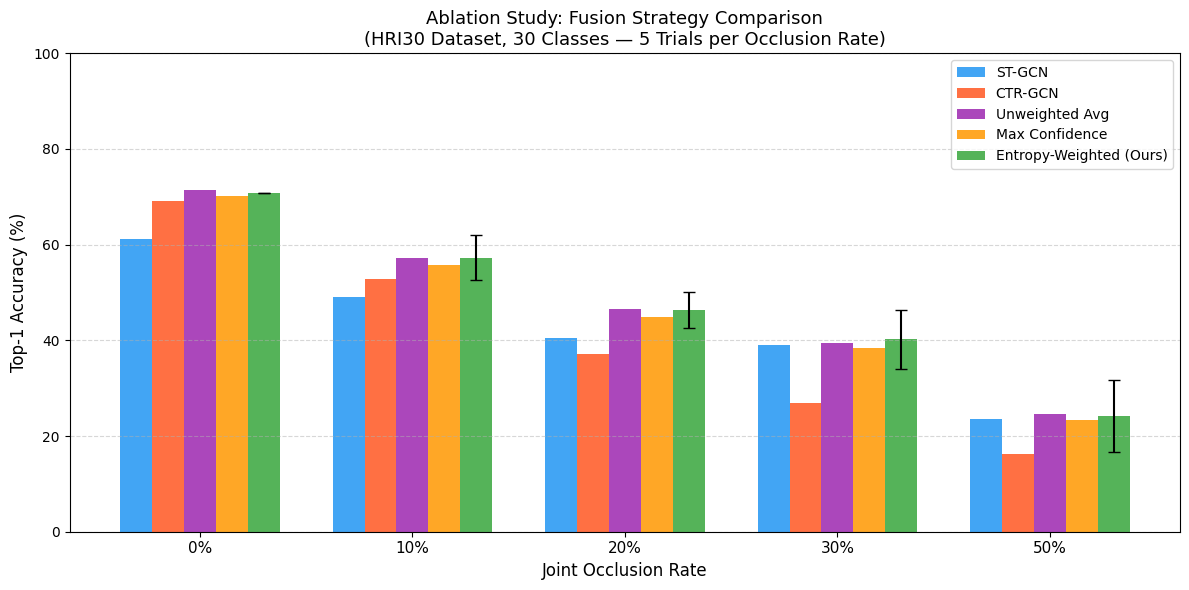


Bar chart: /content/drive/MyDrive/HRC_Research/results/ablation_fusion/ablation_bar_chart.png
CSV:       /content/drive/MyDrive/HRC_Research/results/ablation_fusion/ablation_results.csv


In [ ]:
# Summary table and bar chart — reads from CSV, saves to Drive

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

OUTPUT_DIR = '/content/drive/MyDrive/HRC_Research/results/ablation_fusion'
CSV_PATH   = os.path.join(OUTPUT_DIR, 'ablation_results.csv')

df = pd.read_csv(CSV_PATH)

print("=" * 90)
print("ABLATION: FUSION STRATEGY COMPARISON — HRI30 | 588 test samples | 30 classes")
print("=" * 90)
print(f"{'Rate':<8} {'ST-GCN':>8} {'CTR-GCN':>9} {'Unweighted':>12} {'MaxConf':>10} {'EntropyW':>11} {'Best?':>8}")
print("-" * 90)

for _, row in df.iterrows():
    vals = {
        'Unweighted': row['unweighted_mean'],
        'MaxConf':    row['max_conf_mean'],
        'EntropyW':   row['entropy_w_mean'],
    }
    best_fusion = max(vals, key=vals.get)
    print(f"{row['occlusion_rate']:<8} "
          f"{row['st_mean']:>7.2f}% "
          f"{row['ctr_mean']:>8.2f}% "
          f"{row['unweighted_mean']:>11.2f}% "
          f"{row['max_conf_mean']:>9.2f}% "
          f"{row['entropy_w_mean']:>10.2f}% "
          f"  {best_fusion}")

print("=" * 90)

print("\nImprovement of each fusion strategy over the stronger single model:")
print(f"{'Rate':<8} {'Unweighted':>12} {'MaxConf':>10} {'EntropyW':>11}")
print("-" * 45)
for _, row in df.iterrows():
    best_single = max(row['st_mean'], row['ctr_mean'])
    uw_imp = row['unweighted_mean'] - best_single
    mc_imp = row['max_conf_mean']   - best_single
    ew_imp = row['entropy_w_mean']  - best_single
    print(f"{row['occlusion_rate']:<8} "
          f"{uw_imp:>+11.2f}pp "
          f"{mc_imp:>+9.2f}pp "
          f"{ew_imp:>+10.2f}pp")

rates    = df['occlusion_rate'].tolist()
x        = np.arange(len(rates))
width    = 0.15

fig, ax = plt.subplots(figsize=(12, 6))

b1 = ax.bar(x - 2*width, df['st_mean'],          width, label='ST-GCN',        color='#2196F3', alpha=0.85)
b2 = ax.bar(x -   width, df['ctr_mean'],          width, label='CTR-GCN',       color='#FF5722', alpha=0.85)
b3 = ax.bar(x,           df['unweighted_mean'],   width, label='Unweighted Avg', color='#9C27B0', alpha=0.85)
b4 = ax.bar(x +   width, df['max_conf_mean'],     width, label='Max Confidence', color='#FF9800', alpha=0.85)
b5 = ax.bar(x + 2*width, df['entropy_w_mean'],    width, label='Entropy-Weighted (Ours)', color='#4CAF50', alpha=0.95)

ax.errorbar(x + 2*width, df['entropy_w_mean'], yerr=df['entropy_w_std'],
            fmt='none', color='black', capsize=4, linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(rates, fontsize=11)
ax.set_xlabel('Joint Occlusion Rate', fontsize=12)
ax.set_ylabel('Top-1 Accuracy (%)', fontsize=12)
ax.set_title('Ablation Study: Fusion Strategy Comparison\n'
             '(HRI30 Dataset, 30 Classes — 5 Trials per Occlusion Rate)',
             fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax.set_ylim(0, 100)

plt.tight_layout()

PLOT_PATH = os.path.join(OUTPUT_DIR, 'ablation_bar_chart.png')
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBar chart: {PLOT_PATH}")
print(f"CSV:       {CSV_PATH}")